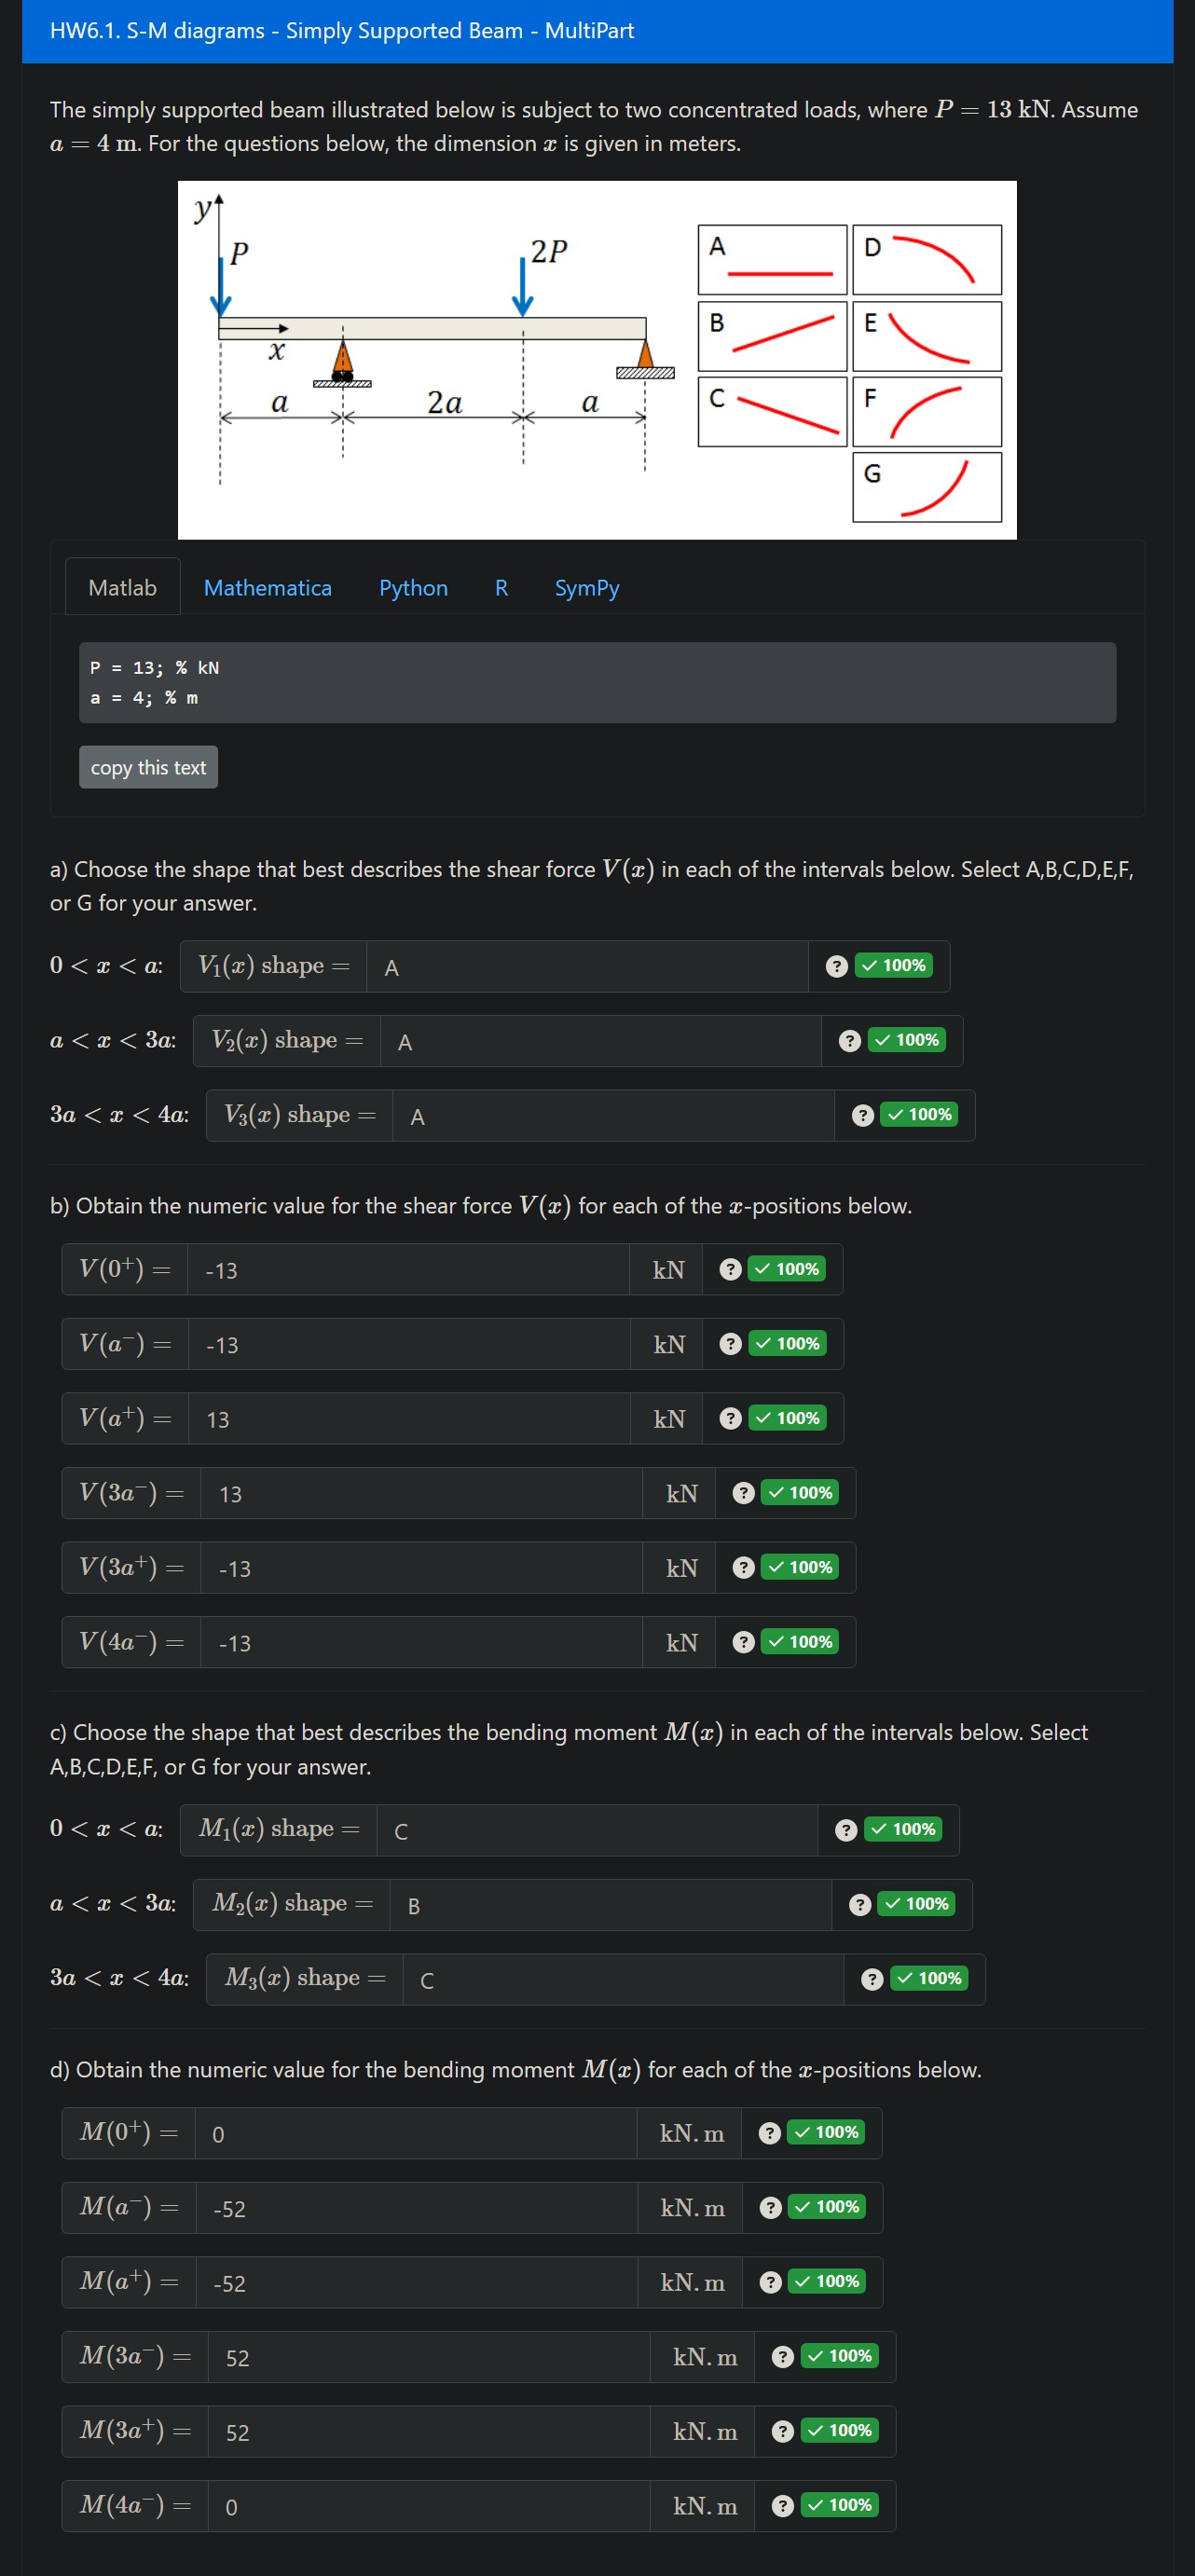

In [ ]:
#HW6.1. S-M diagrams - Simply Supported Beam - MultiPart
import numpy as np

p = 13 # kN
a = 4 # m
f1=2*p #左支点
f2=p #右支点
print("A")
print("A")
print("A")
print("v(0+)=",-p,"kN")
print("v(a-)=",-p,"kN")
print("v(a+)=",p,"kN")
print("v(3a-)=",p,"kN")
print("v(3a+)=",-p,"kN")
print("v(4a-)=",-p,"kN")
print("C")
print("B")
print("C")
print("M(0+)=",0,"kN*m")
print("M(a-)=",-p*a,"kN*m")
print("M(a+)=",-p*a,"kN*m")
print("M(3a-)=",p*a,"kN*m")
print("M(3a+)=",p*a,"kN*m")
print("M(4a-)=",0,"kN*m")

In [ ]:
##HW6.2. S-M diagrams - Simply Supported Beam - v2 - MultiPart
import numpy as np

# 1. 定义已知量
w = 11  # kN/m
a = 2   # m
M_o = 3 * w * (a**2)  # kN.m

# 2. 计算支座反力
# sum(M_at_a) = -w*(2a)*a + R2*(3a) + M_o = 0
R2 = (w * 2 * a * a - M_o) / (3 * a)
R1 = (w * 2 * a) - R2

# 3. 计算关键位置的剪力 V (kN)
V_0_plus = 0
V_a_minus = 0
V_a_plus = R1
V_3a_minus = R1 - w * (2 * a)
V_3a_plus = V_3a_minus
V_4a_minus = V_3a_plus

# 4. 计算关键位置的弯矩 M (kN.m)
M_0_plus = 0
M_a_minus = 0
M_a_plus = 0
# 面积法计算 M(3a)
M_3a = M_a_plus + (V_a_plus + V_3a_minus) / 2 * (2 * a)
M_4a_minus = M_3a + V_3a_plus * a

# 打印结果
print(f"--- 剪力 V (kN) ---")
print(f"V(0+)  = {V_0_plus}")
print(f"V(a-)  = {V_a_minus}")
print(f"V(a+)  = {V_a_plus:.10f}")
print(f"V(3a-) = {V_3a_minus:.10f}")
print(f"V(3a+) = {V_3a_plus:.10f}")
print(f"V(4a-) = {V_4a_minus:.10f}")

print(f"\n--- 弯矩 M (kN.m) ---")
print(f"M(0+)  = {M_0_plus}")
print(f"M(a-)  = {M_a_minus}")
print(f"M(a+)  = {M_a_plus}")
print(f"M(3a-)  = {M_3a:.10f}")
print(f"M(3a+)  = {M_3a:.10f}")
print(f"M(4a-) = {M_4a_minus:.10f}")

#ACA AFB


In [ ]:
#HW6.3. S-M equations - SSB
import sympy as sp

# 1. 定义已知参数
w_val = 8   # 均布载荷 kN/m
P_val = 12  # 集中力 kN
a_val = 5   # 间距 m

# 定义符号变量
x = sp.symbols('x')
R1, R2 = sp.symbols('R1 R2') # 支座反力：R1在 x=a，R2在 x=3a

# --- 2. 计算支座反力 ---
# 对 R2 点取矩平衡 (ΣM_R2 = 0)
# 均布载荷矩：w * a * (3a - a/2)
# R1 矩：-R1 * 2a
# P 矩：P * a
eq_mom = w_val * a_val * (3 * a_val - a_val / 2) - R1 * (2 * a_val) + P_val * a_val
r1_sol = sp.solve(eq_mom, R1)[0]

# 竖向力平衡 (ΣFy = 0)
eq_fy = r1_sol + R2 - w_val * a_val - P_val
r2_sol = sp.solve(eq_fy, R2)[0]

print(f"支座反力计算结果: R1 = {r1_sol} kN, R2 = {r2_sol} kN\n")

# --- 3. 定义分段函数 ---
def get_internal_forces(x_val):
    # 初始化剪力 V
    # 均布载荷作用在 0 < x < a
    # R1 作用在 x = a
    # P 作用在 x = 2a
    
    # 剪力 V(x) 定义:
    # 均布载荷贡献: -w * x (如果 x < a) 否则 -w * a
    v_w = sp.Piecewise((w_val * x, x < a_val), (w_val * a_val, True))
    # 集中力 R1 贡献: -R1 (如果 x > a)
    v_r1 = sp.Piecewise((0, x < a_val), (r1_sol, True))
    # 集中力 P 贡献: +P (如果 x > 2a)
    v_p = sp.Piecewise((0, x < 2 * a_val), (P_val, True))
    
    # 根据标准符号规定 (向下为正负载荷): V(x) = ΣFy_left
    # 这里我们采用题目截图中的正负号习惯
    v_expr = -v_w + v_r1 - v_p
    
    # 弯矩 M(x) = ∫ V(x) dx
    # 注意：需要分段积分并保证连续性，或者直接由截面法列式
    return sp.simplify(v_expr)

# --- 4. 打印各区间表达式 ---
intervals = [
    (0, a_val, "0 < x < a"),
    (a_val, 2 * a_val, "a < x < 2a"),
    (2 * a_val, 3 * a_val, "2a < x < 3a")
]

for start, end, label in intervals:
    # 截面法推导
    mid = (start + end) / 2
    
    # 剪力 V(x)
    if start == 0:
        v_x = -w_val * x
    elif start == a_val:
        v_x = -w_val * a_val + r1_sol
    else:
        v_x = -w_val * a_val + r1_sol - P_val
        
    # 弯矩 M(x) 通过截面法：对截面取矩
    if start == 0:
        m_x = -(w_val * x**2) / 2
    elif start == a_val:
        m_x = -(w_val * a_val) * (x - a_val/2) + r1_sol * (x - a_val)
    else:
        m_x = -(w_val * a_val) * (x - a_val/2) + r1_sol * (x - a_val) - P_val * (x - 2*a_val)

    print(f"--- 区间 {label} ---")
    print(f"V(x) = {sp.expand(v_x)}")
    print(f"M(x) = {sp.expand(m_x)}\n")

In [ ]:
#HW6.4. Simply supported beam with concentrated load
import numpy as np
import matplotlib.pyplot as plt

# ---------------------- 1. 梁参数设定 ----------------------
L = 2.0    # 梁总长度（可修改，取2方便计算中点位置）
P = 1.0    # 中点集中力大小（可修改，取1为单位力）
R1 = P / 2 # 左支座反力
R2 = P / 2 # 右支座反力
M_max = P * L / 4 # 中点最大弯矩

# ---------------------- 2. 创建画布与子图 ----------------------
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 12), dpi=100)

# ---------------------- 3. 自由体图 (FBD) ----------------------
ax1.set_title("Free-Body Diagram (FBD)", fontsize=14, pad=15)
# 绘制梁主体
ax1.plot([0, L], [0, 0], 'k-', linewidth=3)
# 绘制左支座反力（向上）
ax1.arrow(0, 0, 0, R1*0.8, head_width=0.05, head_length=0.05, fc='k', ec='k')
ax1.text(-0.1, R1*0.4, r'$R_1 = \frac{P}{2}$', ha='right', va='center', fontsize=12)
# 绘制右支座反力（向上）
ax1.arrow(L, 0, 0, R2*0.8, head_width=0.05, head_length=0.05, fc='k', ec='k')
ax1.text(L+0.1, R2*0.4, r'$R_2 = \frac{P}{2}$', ha='left', va='center', fontsize=12)
# 绘制中点集中力（向下）
ax1.arrow(L/2, 0, 0, -P*0.8, head_width=0.05, head_length=0.05, fc='r', ec='r')
ax1.text(L/2, -P*0.4, r'$P$', ha='center', va='center', fontsize=12, color='r')
# 坐标轴设置
ax1.set_xlim(-0.2, L + 0.2)
ax1.set_ylim(-P*1.2, P*1.2)
ax1.set_xticks([0, L/2, L])
ax1.set_xticklabels(['$0$', r'$\frac{L}{2}$', '$L$'], fontsize=12)
ax1.set_yticks([])  # 隐藏y轴刻度
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.axvline(x=L/2, color='blue', linestyle=':', alpha=0.7) # 中点虚线

# ---------------------- 4. 剪力图 (Shear Force Diagram) ----------------------
ax2.set_title("Shear Force Diagram ($V$)", fontsize=14, pad=15)
# 生成x坐标数据
x_v1 = np.linspace(0, L/2, 100)
x_v2 = np.linspace(L/2, L, 100)
# 剪力值
V1 = R1 * np.ones_like(x_v1)  # 左半段：+P/2
V2 = -R2 * np.ones_like(x_v2) # 右半段：-P/2
# 绘制剪力线
ax2.plot(x_v1, V1, 'b-', linewidth=2.5)
ax2.plot(x_v2, V2, 'b-', linewidth=2.5)
# 绘制中点突变线
ax2.plot([L/2, L/2], [R1, -R2], 'b--', linewidth=1.5)
# 坐标轴与刻度
ax2.set_xlim(-0.1, L + 0.1)
ax2.set_ylim(-P*0.6, P*0.6)
ax2.set_xticks([0, L/2, L])
ax2.set_xticklabels(['$0$', r'$\frac{L}{2}$', '$L$'], fontsize=12)
ax2.set_yticks([-P/2, 0, P/2])
ax2.set_yticklabels([r'$-\frac{P}{2}$', '$0$', r'$\frac{P}{2}$'], fontsize=12)
ax2.set_ylabel('$V$', fontsize=14)
ax2.set_xlabel('$x$', fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.7)
# 辅助虚线（对应题目网格）
ax2.axvline(x=L/2, color='c', linestyle='--', alpha=0.5)
ax2.axvline(x=L, color='c', linestyle='--', alpha=0.5)
ax2.axhline(y=P/2, color='c', linestyle='--', alpha=0.5)
ax2.axhline(y=-P/2, color='c', linestyle='--', alpha=0.5)
ax2.axhline(y=0, color='k', linestyle='-', alpha=0.8)

# ---------------------- 5. 弯矩图 (Bending Moment Diagram) ----------------------
ax3.set_title("Bending Moment Diagram ($M$)", fontsize=14, pad=15)
# 生成x坐标数据
x_m1 = np.linspace(0, L/2, 100)
x_m2 = np.linspace(L/2, L, 100)
# 弯矩值
M1 = R1 * x_m1                  # 左半段：M = (P/2)x
M2 = R1 * x_m2 - P*(x_m2 - L/2) # 右半段：M = PL/2 - (P/2)x
# 绘制弯矩线
ax3.plot(x_m1, M1, 'r-', linewidth=2.5)
ax3.plot(x_m2, M2, 'r-', linewidth=2.5)
# 坐标轴与刻度
ax3.set_xlim(-0.1, L + 0.1)
ax3.set_ylim(-M_max*0.2, M_max*1.2)
ax3.set_xticks([0, L/2, L])
ax3.set_xticklabels(['$0$', r'$\frac{L}{2}$', '$L$'], fontsize=12)
# y轴刻度（按题目要求标注PL/4, PL/8等）
yticks = [-M_max, -M_max/2, 0, M_max/2, M_max]
yticklabels = [r'$-\frac{PL}{4}$', r'$-\frac{PL}{8}$', '$0$', r'$\frac{PL}{8}$', r'$\frac{PL}{4}$']
ax3.set_yticks(yticks)
ax3.set_yticklabels(yticklabels, fontsize=12)
ax3.set_ylabel('$M$', fontsize=14)
ax3.set_xlabel('$x$', fontsize=14)
ax3.grid(True, linestyle='--', alpha=0.7)
# 辅助虚线（对应题目网格）
ax3.axvline(x=L/2, color='c', linestyle='--', alpha=0.5)
ax3.axvline(x=L, color='c', linestyle='--', alpha=0.5)
ax3.axhline(y=M_max, color='c', linestyle='--', alpha=0.5)
ax3.axhline(y=M_max/2, color='c', linestyle='--', alpha=0.5)
ax3.axhline(y=-M_max/2, color='c', linestyle='--', alpha=0.5)
ax3.axhline(y=-M_max, color='c', linestyle='--', alpha=0.5)
ax3.axhline(y=0, color='k', linestyle='-', alpha=0.8)

# ---------------------- 6. 调整布局并显示 ----------------------
plt.tight_layout()
plt.show()


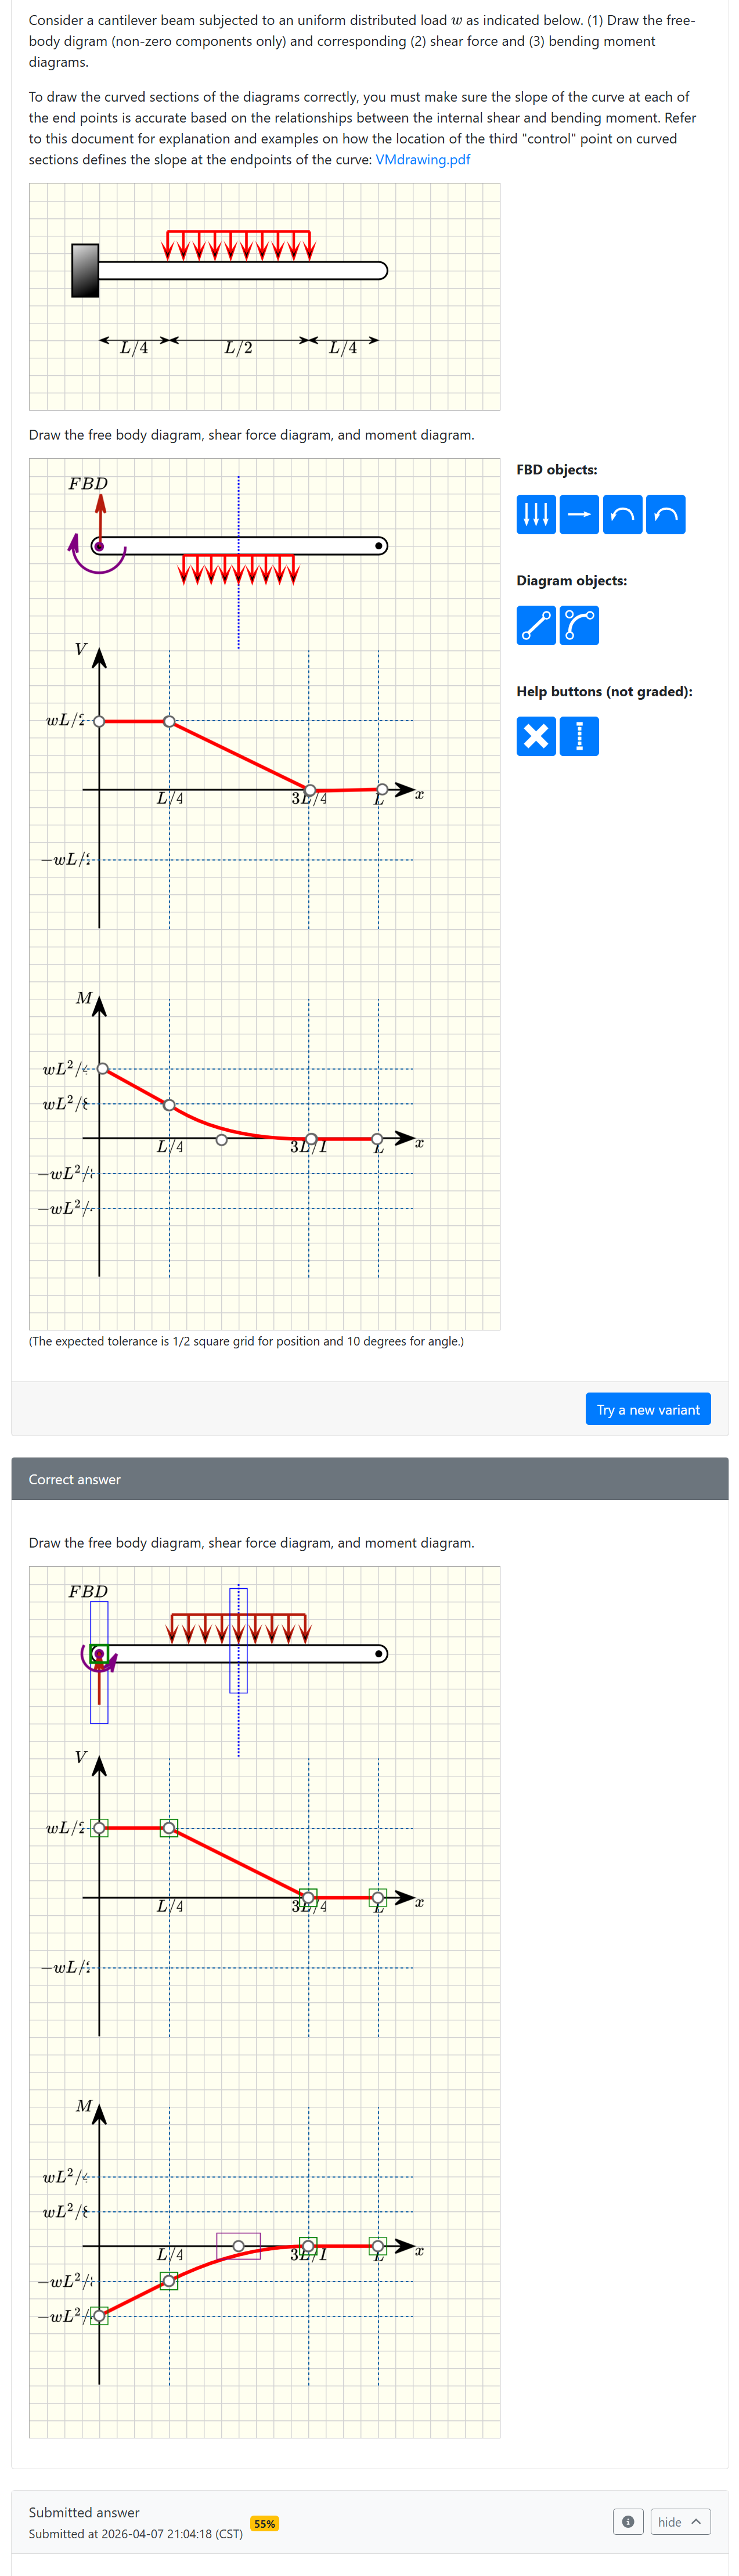

In [ ]:
#HW6.5. Cantilever-VMdiagrams
import numpy as np
import matplotlib.pyplot as plt

# ---------------------- 1. 梁参数设定 ----------------------
L = 2.0        # 梁总长度（单位长度，对应题目网格）
w = 1.0        # 均布荷载集度（单位力/长度）
load_start = L/4  # 荷载起始位置
load_end = 3*L/4  # 荷载结束位置
load_length = load_end - load_start  # 荷载长度 L/2

# 左侧固定端反力与反弯矩（平衡计算）
R = w * load_length          # 向上的支座反力（平衡总荷载）
M_fixed = -R * L + w*load_length*(L - load_start - load_length/2)  
# 固定端弯矩（负号表示与题目图示同向，使梁上部受拉）

# ---------------------- 2. 创建画布与子图 ----------------------
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 12), dpi=100)

# ---------------------- 3. 自由体图 (FBD) ----------------------
ax1.set_title("Free-Body Diagram (FBD)", fontsize=14, pad=15)
# 绘制梁主体
ax1.plot([0, L], [0, 0], 'k-', linewidth=3)
# 绘制固定端（黑色矩形块）
ax1.add_patch(plt.Rectangle((-0.15, -0.2), 0.15, 0.4, color='black'))
# 支座反力（向上）
ax1.arrow(0, 0, 0, R*0.8, head_width=0.03, head_length=0.03, fc='green', ec='green')
ax1.text(-0.12, R*0.4, r'$R=\frac{wL}{2}$', fontsize=11, color='green')
# 固定端弯矩（逆时针弯箭头，匹配题目紫色箭头）
theta = np.linspace(np.pi/2, 3*np.pi/2, 50)  # 半圆轨迹
arc_x = 0.1 * np.cos(theta)
arc_y = 0.1 * np.sin(theta)
ax1.plot(arc_x, arc_y, 'purple', linewidth=2)
ax1.arrow(arc_x[-2], arc_y[-2], arc_x[-1]-arc_x[-2], arc_y[-1]-arc_y[-2], 
          head_width=0.02, head_length=0.02, fc='purple', ec='purple')
ax1.text(-0.22, 0.05, r'$M=\frac{wL^2}{4}$', fontsize=11, color='purple')
# 均布荷载（红色向下箭头）
load_x = np.linspace(load_start, load_end, 10)
for x in load_x:
    ax1.arrow(x, 0, 0, -0.15, head_width=0.02, head_length=0.02, fc='red', ec='red')
ax1.text((load_start+load_end)/2, -0.25, r'$w$', fontsize=12, color='red')
# 坐标轴设置
ax1.set_xlim(-0.3, L+0.1)
ax1.set_ylim(-0.5, R*1.2)
ax1.set_xticks([0, L/4, 3*L/4, L])
ax1.set_xticklabels(['$0$', r'$\frac{L}{4}$', r'$\frac{3L}{4}$', '$L$'], fontsize=12)
ax1.set_yticks([])
ax1.grid(True, linestyle='--', alpha=0.5)

# ---------------------- 4. 剪力图 (Shear Force Diagram) ----------------------
ax2.set_title("Shear Force Diagram ($V$)", fontsize=14, pad=15)
# 分段定义剪力函数（左侧隔离体，向上为正）
def V(x):
    if x < load_start:
        return R  # 荷载前：剪力恒定为 R
    elif load_start <= x <= load_end:
        return R - w*(x - load_start)  # 荷载中：线性递减
    else:
        return 0  # 荷载后：剪力为 0

# 生成各段数据
x1 = np.linspace(0, load_start, 100)
x2 = np.linspace(load_start, load_end, 100)
x3 = np.linspace(load_end, L, 100)
V1 = [R for _ in x1]
V2 = [R - w*(x - load_start) for x in x2]
V3 = [0 for _ in x3]

# 绘图
ax2.plot(x1, V1, 'b-', linewidth=2.5)
ax2.plot(x2, V2, 'b-', linewidth=2.5)
ax2.plot(x3, V3, 'b-', linewidth=2.5)
# 刻度与网格
ax2.set_xlim(-0.1, L+0.1)
ax2.set_ylim(-R*0.5, R*1.1)
ax2.set_xticks([0, L/4, 3*L/4, L])
ax2.set_xticklabels(['$0$', r'$\frac{L}{4}$', r'$\frac{3L}{4}$', '$L$'], fontsize=12)
ax2.set_yticks([-R, 0, R])
ax2.set_yticklabels([r'$-\frac{wL}{2}$', '$0$', r'$\frac{wL}{2}$'], fontsize=12)
ax2.set_ylabel('$V$', fontsize=14)
ax2.set_xlabel('$x$', fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.5)
# 题目对应虚线
ax2.axvline(L/4, color='cyan', linestyle='--', alpha=0.5)
ax2.axvline(3*L/4, color='cyan', linestyle='--', alpha=0.5)
ax2.axhline(0, color='black', linewidth=1)

# ---------------------- 5. 弯矩图 (Bending Moment Diagram) ----------------------
ax3.set_title("Bending Moment Diagram ($M$)", fontsize=14, pad=15)
# 分段定义弯矩函数（左侧累加，负号对齐题目网格）
def M(x):
    if x < load_start:
        return M_fixed + R*x  # 荷载前：线性变化
    elif load_start <= x <= load_end:
        return M_fixed + R*x - 0.5*w*(x - load_start)**2  # 荷载中：抛物线
    else:
        return 0  # 荷载后：0

# 生成各段数据
M1 = [M_fixed + R*x for x in x1]
M2 = [M_fixed + R*x - 0.5*w*(x - load_start)**2 for x in x2]
M3 = [0 for _ in x3]

# 绘图
ax3.plot(x1, M1, 'r-', linewidth=2.5)
ax3.plot(x2, M2, 'r-', linewidth=2.5)
ax3.plot(x3, M3, 'r-', linewidth=2.5)
# 刻度与网格（对齐题目标注）
ax3.set_xlim(-0.1, L+0.1)
ax3.set_ylim(-w*L**2/3, w*L**2/3)
ax3.set_xticks([0, L/4, 3*L/4, L])
ax3.set_xticklabels(['$0$', r'$\frac{L}{4}$', r'$\frac{3L}{4}$', '$L$'], fontsize=12)
yticks = [-w*L**2/2, -w*L**2/4, 0, w*L**2/8, w*L**2/4]
ax3.set_yticks(yticks)
ax3.set_yticklabels([r'$-\frac{wL^2}{2}$', r'$-\frac{wL^2}{4}$', '$0$', r'$\frac{wL^2}{8}$', r'$\frac{wL^2}{4}$'], fontsize=11)
ax3.set_ylabel('$M$', fontsize=14)
ax3.set_xlabel('$x$', fontsize=14)
ax3.grid(True, linestyle='--', alpha=0.5)
# 题目对应虚线
ax3.axvline(L/4, color='cyan', linestyle='--', alpha=0.5)
ax3.axvline(3*L/4, color='cyan', linestyle='--', alpha=0.5)
for y in yticks:
    ax3.axhline(y, color='cyan', linestyle='--', alpha=0.5)
ax3.axhline(0, color='black', linewidth=1)

# ---------------------- 6. 显示图像 ----------------------
plt.tight_layout()
plt.show()

#从固定端往自由端算

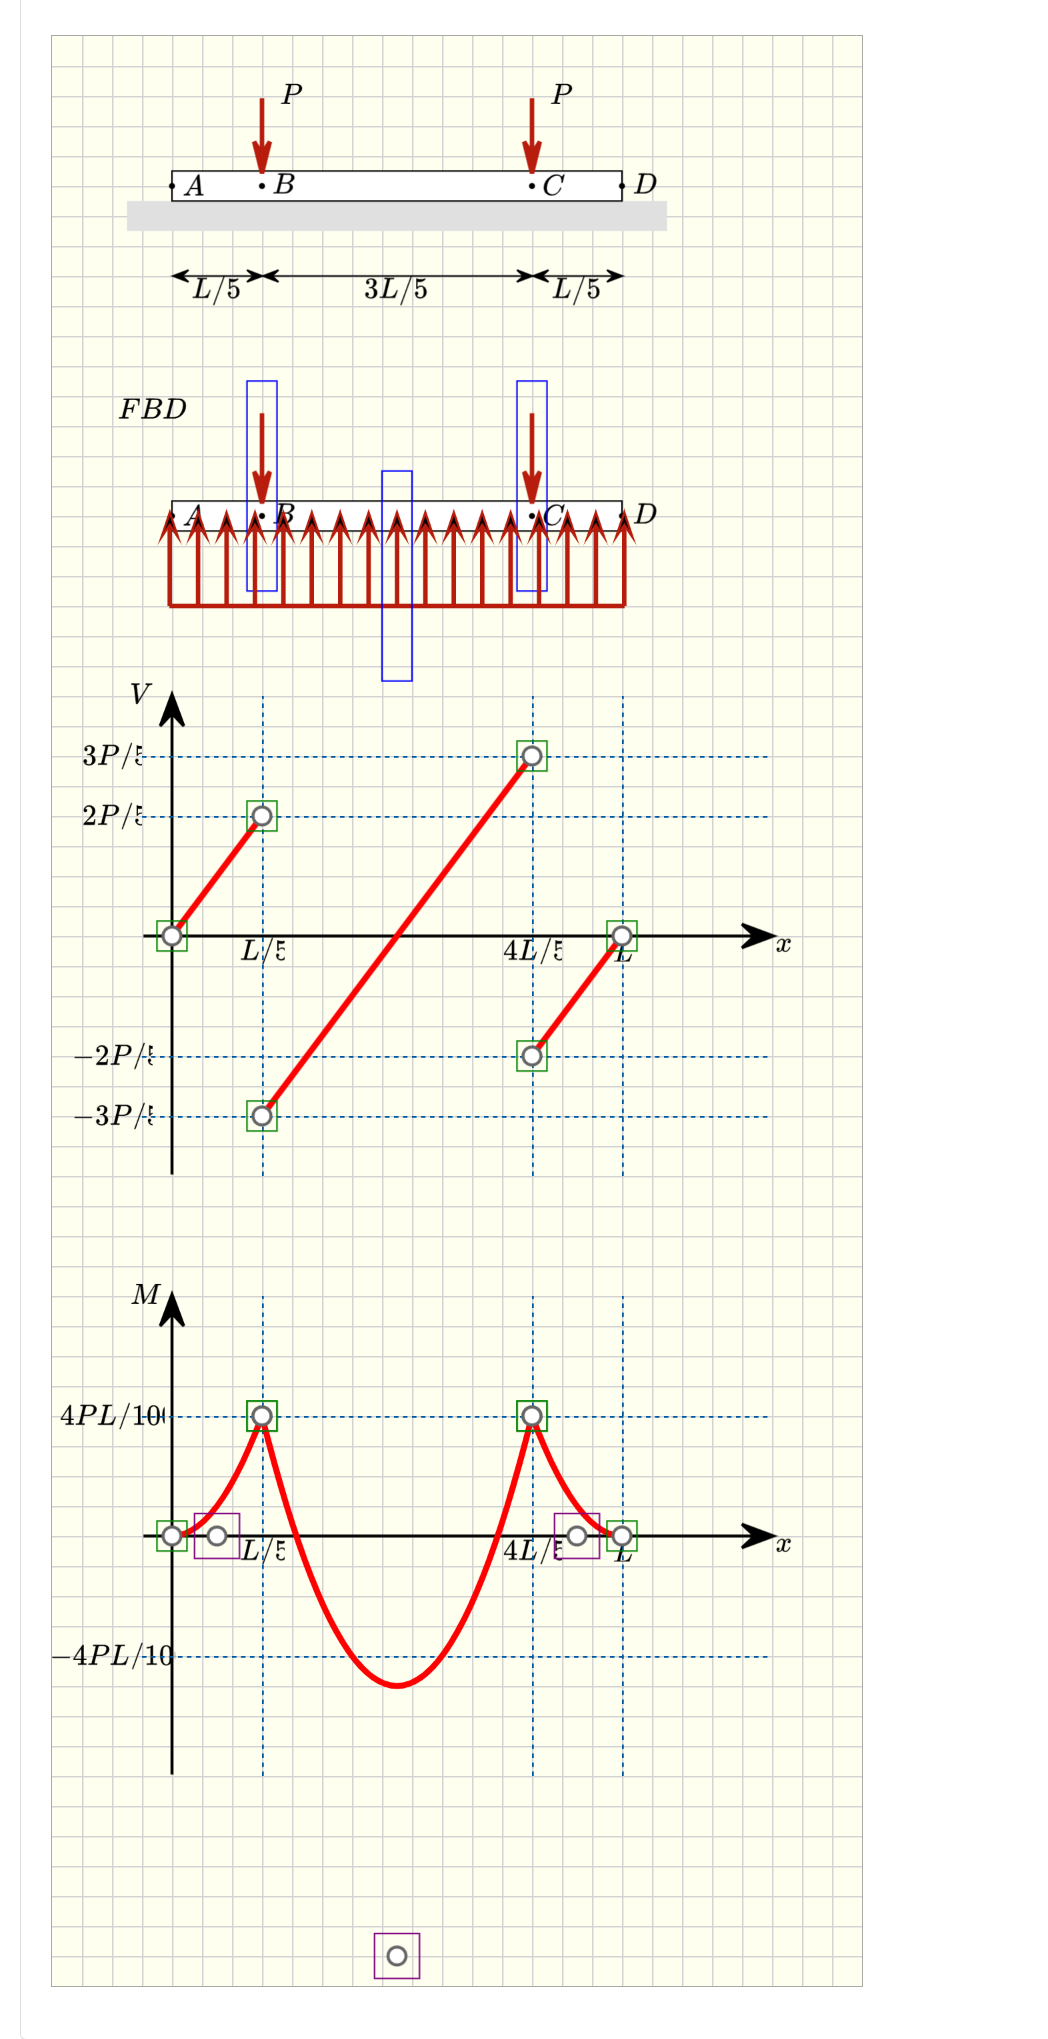

In [ ]:
#HW6.7. Bending Box-channel - MultiPart
import numpy as np

h = 152 # mm
b = 232 # mm
t1 = 20 # mm
t2 = 24 # mm
Mz = 1281 # N.m

H = h + 2 * t2
B = b + 2 * t1
A1 = B * H
y1 = H / 2  # 大矩形形心y坐标
A2 = b * h
y2 = t2 + h / 2  # 小矩形形心y坐标
y_hat = (A1 * y1 - A2 * y2) / (A1 - A2)
print(y_hat)

Ic=(2*t1+b)*(h+2*t2)**3/12-b*h**3/12
I=Ic+(2*b*t2+t1*(h+2*t2)*2)*(t2+h/2-y_hat)
print(I/10**6)
sigma=Mz*y_hat/10**6/I

y_max = max(abs(0 - y_hat), abs(H - y_hat))  # 最大y距离
sigma = (Mz * y_max*0.001) / (I*10**-12)/1000000
print(f"最大正应力 |σ| = ",sigma, "MPa")

In [ ]:
#HW6.8. Bending Extruded - v2 - MultiPart
import numpy as np
t = 18 # mm
Mz = -1692 # N.m
H=10*t
B=4*t
h=4*t
b=2*t
a1=B*H
a2=b*h

yz=(a1*H/2-a2*(t+h/2))/(a1-a2)
y_hat=yz-3*t
print(y_hat)

i1=B*H**3/12+B*H*(yz-H/2)**2
i2=b*h**3/12+b*h*(yz-(t+h/2))**2
I=i1-i2
print(I/10**6)

sigma=Mz*1000*(y_hat+3*t)/I
print(f"最大正应力 |σ| = ",abs(sigma), "MPa")




In [ ]:

#HW6.9. Bending Fancy 2 - MultiPart
import numpy as np

r = 24 # mm
Mz = 1783 # N.m

a1=np.pi*r*5*r
a2=np.pi*r**2

yz=(a1*5*r/2-a2*r*2)/(a1-a2)
y_hat=yz-2*r
print(y_hat)

i1=np.pi*r*r**3/12+np.pi*r*r*(2.5*r-y_hat)**2
i2=61*np.pi*r**4/12+(np.pi*r*4*r-a2)*y_hat**2
I=i1+i2
print(I/10**6)

sigma=Mz*1000*(y_hat+2*r)/I
print(f"最大正应力 |σ| = ",abs(sigma), "MPa")

In [ ]:
#HW6.10. Bending Hollow Rectangle1 - Centroid
import numpy as np

t = 20 # mm
a = 58 # mm

a1=8*t*12*t
a2=6*t*2*t
y1=6*t   #大矩形形心y坐标
y2=6*t-a-t    #小矩形形心y坐标(会变)

yz=(a1*y1-a2*y2)/(a1-a2)
y_hat=yz-6*t
print(y_hat)



In [ ]:
#HW6.11. Bending Hollow Rectangle2 - Moment of Inertia
import numpy as np

t = 20 # mm
a = 20 # mm
r = 40 # mm
ybar = 2.1977 # mm

a1=8*t*14*t
a2=r**2*np.pi/2

y1=7*t   #大矩形形心y坐标
y2=7*t-a-4*r/3/np.pi    #小矩形形心y坐标
i1=8*t*(14*t)**3/12+8*t*14*t*ybar**2
i2=(np.pi/8-8/9/np.pi)*r**4+np.pi*r**2/2*(ybar+a+4*r/3/np.pi)**2
I=i1-i2
print(I/10**6)


In [ ]:
#HW6.12. Cantilever beam design
import numpy as np

a = 1659 # mm
b = 249 # mm
h = 144 # mm
t1 = 21 # mm
t2 = 25 # mm
sigmaT = 10 # MPa
sigmaC = 14 # MPa

a1=b*(h+t2)
a2=(b-2*t1)*h
y1=(h+t2)/2  
y2=h/2

y_hat=(a1*y1-a2*y2)/(a1-a2)
print(y_hat)

i1=b*(h+t2)**3/12+a1*(y_hat-(h+t2)/2)**2
i2=(b-2*t1)*h**3/12+a2*(y_hat-h/2)**2
I=i1-i2
print(I/10**6)






In [ ]:
#HW6.12. Cantilever beam design
import numpy as np

# 1. 输入已知参数 (单位: mm, MPa)
a = 1659 
b = 249 
h = 144 
t1 = 21 
t2 = 25 
sigmaT = 10 # 许用拉应力
sigmaC = 14 # 许用压应力

# 2. 计算截面几何性质
# 将截面分为三个部分：顶部横梁 (f) 和两个侧壁 (w)
A_f = b * t2
y_f = h + t2 / 2  # 顶部横梁形心高度

A_w = 2 * (t1 * h)
y_w = h / 2       # 侧壁形心高度

A_total = A_f + A_w

# 计算形心 y_bar (相对于 z' 轴)
y_bar = (A_f * y_f + A_w * y_w) / A_total

# 计算惯性矩 Iz (关于形心轴 z，使用平行轴定理)
# 顶部横梁的惯性矩
I_f = (1/12) * b * (t2**3) + A_f * (y_f - y_bar)**2
# 侧壁的惯性矩
I_w = 2 * ((1/12) * t1 * (h**3) + (t1 * h) * (y_w - y_bar)**2)
I_z = I_f + I_w

M_pos_coeff = 0.5 * a**2
M_neg_coeff = -1.5 * a**2

# 4. 计算应力限制下的 w
# 截面上下边缘到形心轴的距离
c_top = (h + t2) - y_bar
c_bot = y_bar

# 定义可能的失效情况列表
w_limits = []

# 情况 A: 在最大负弯矩处 (M = -1.5*w*a^2)
# 负弯矩导致顶部受拉，底部受压
w_limits.append(sigmaT * I_z / (abs(M_neg_coeff) * c_top)) # 顶部拉应力限制
w_limits.append(sigmaC * I_z / (abs(M_neg_coeff) * c_bot)) # 底部压应力限制

# 情况 B: 在最大正弯矩处 (M = 0.5*w*a^2)
# 正弯矩导致底部受拉，顶部受压
w_limits.append(sigmaT * I_z / (M_pos_coeff * c_bot))     # 底部拉应力限制
w_limits.append(sigmaC * I_z / (M_pos_coeff * c_top))     # 顶部压应力限制

# 取最小值以确保安全
w_max = min(w_limits)

# 打印结果
#print(f"y_bar = {y_bar:.10f} mm")
#print(f"I_z = {I_z / 1e6:.10f} x 10^6 mm^4")
print(f"w = {w_max:.10f} N/mm")

w = 0.9648109510 N/mm
